# W2 D26 — Open Practice: Stroke Prediction
**Topics:** Stroke dataset (Kaggle) | Full pipeline, imbalanced classes, XGBoost, SHAP

**Q1** EDA — stroke rate by risk factors
**Q2** Preprocessing pipeline (missing data, encoding)
**Q3** XGBoost with SMOTE
**Q4** Threshold tuning (Recall focus)
**Q5** SHAP feature importance


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')

Libraries loaded


In [2]:
# Try Kaggle stroke dataset, fall back to synthetic
try:
    import subprocess
    subprocess.run(['kaggle','datasets','download','-d','fedesoriano/stroke-prediction-dataset','--unzip','-p','/tmp/stroke'], capture_output=True)
    df = pd.read_csv('/tmp/stroke/healthcare-dataset-stroke-data.csv')
    print(f'Stroke dataset loaded: {df.shape}')
except:
    print('Generating synthetic stroke dataset')
    n = 5110
    np.random.seed(420)
    age = np.random.normal(43, 22, n).clip(0, 90)
    hypertension = (np.random.rand(n) < 0.1).astype(int)
    heart_disease = (np.random.rand(n) < 0.054).astype(int)
    avg_glucose = np.random.normal(106, 45, n).clip(50, 300)
    bmi = np.random.normal(28.9, 7.9, n).clip(10, 60)
    ever_married = np.random.choice(['Yes','No'], n, p=[0.66, 0.34])
    smoking = np.random.choice(['never smoked','formerly smoked','smokes','Unknown'], n, p=[0.37,0.17,0.16,0.30])
    work_type = np.random.choice(['Private','Self-employed','Govt_job','children','Never_worked'], n, p=[0.57,0.16,0.13,0.13,0.01])
    residence = np.random.choice(['Urban','Rural'], n, p=[0.51, 0.49])
    logit = -6 + 0.06*age + 0.5*hypertension + 0.5*heart_disease + 0.005*avg_glucose + 0.02*(bmi-25)
    prob = 1/(1+np.exp(-logit))
    stroke = (np.random.rand(n) < prob).astype(int)
    df = pd.DataFrame({'age':age,'hypertension':hypertension,'heart_disease':heart_disease,
                       'avg_glucose_level':avg_glucose,'bmi':bmi,'ever_married':ever_married,
                       'smoking_status':smoking,'work_type':work_type,'Residence_type':residence,'stroke':stroke})
    print(f'Synthetic stroke: {df.shape}, stroke rate={stroke.mean():.2%}')

Generating synthetic stroke dataset
Synthetic stroke: (5110, 10), stroke rate=10.92%


In [3]:
display(df.head())

,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married,smoking_status,work_type,Residence_type,stroke
0,32.321401,0,0,81.932402,40.650928,No,Unknown,Private,Urban,0
1,1.086615,0,0,50.000000,48.285475,No,Unknown,Private,Urban,0
2,31.423120,0,0,106.443989,37.999563,Yes,never smoked,Private,Urban,0
3,36.101988,0,0,168.946922,25.772661,No,never smoked,Private,Urban,0
4,50.275543,0,0,149.167247,33.130193,Yes,Unknown,Govt_job,Rural,0


## Q1 — EDA: Stroke Rate by Risk Factors

Overall Baseline Stroke Rate: 10.92%

Stroke Rate by Hypertension status:
hypertension
0    10.39%
1    15.43%
Name: stroke, dtype: object 

Stroke Rate by Heart Disease status:
heart_disease
0    10.47%
1    18.47%
Name: stroke, dtype: object


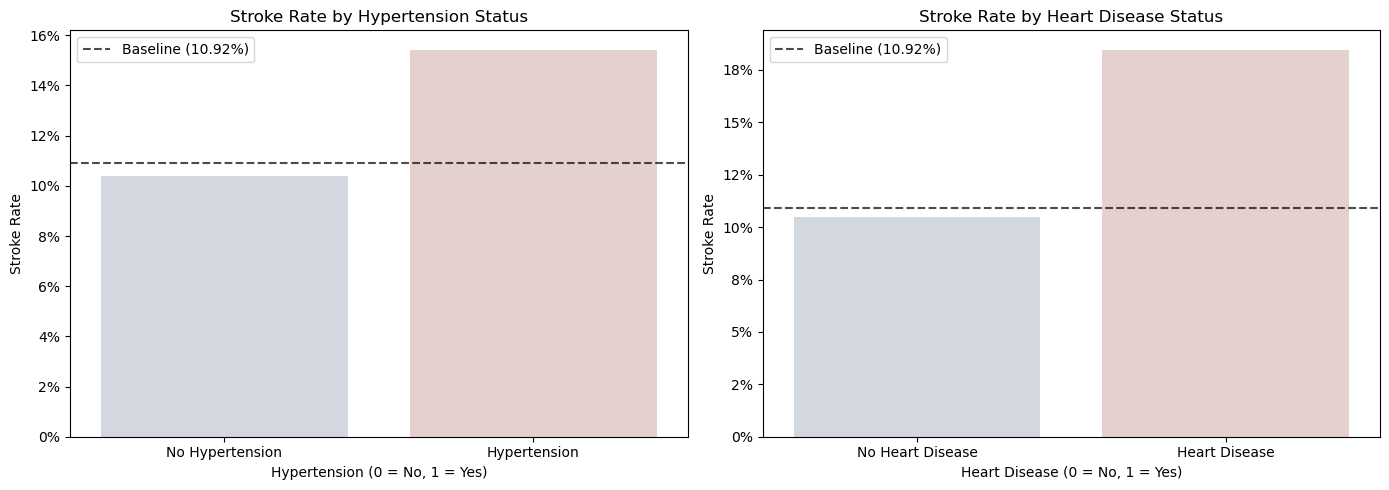

In [13]:
# 1. Stroke Rate by Binary Medical Risk Factors

# Calculate baseline overall stroke rate for comparison
baseline_rate = df['stroke'].mean()
print(f"Overall Baseline Stroke Rate: {baseline_rate:.2%}\n")

# Group by Hypertension
hyp_rates = df.groupby('hypertension')['stroke'].mean()
print("Stroke Rate by Hypertension status:")
print(hyp_rates.map('{:.2%}'.format), "\n")

# Group by Heart Disease
hd_rates = df.groupby('heart_disease')['stroke'].mean()
print("Stroke Rate by Heart Disease status:")
print(hd_rates.map('{:.2%}'.format))

# Set up side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Hypertension Stroke Rate
sns.barplot(
    ax=axes[0], 
    x=hyp_rates.index, 
    y=hyp_rates.values, 
    palette='vlag', 
    hue=hyp_rates.index, 
    legend=False,
    alpha=0.7
)
axes[0].axhline(baseline_rate, color='black', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_rate:.2%})')
axes[0].set_title('Stroke Rate by Hypertension Status')
axes[0].set_xlabel('Hypertension (0 = No, 1 = Yes)')
axes[0].set_ylabel('Stroke Rate')
axes[0].set_xticklabels(['No Hypertension', 'Hypertension'])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend()

# Plot Heart Disease Stroke Rate
sns.barplot(
    ax=axes[1], 
    x=hd_rates.index, 
    y=hd_rates.values, 
    palette='vlag', 
    hue=hd_rates.index, 
    legend=False,
    alpha=0.7
)
axes[1].axhline(baseline_rate, color='black', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_rate:.2%})')
axes[1].set_title('Stroke Rate by Heart Disease Status')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Stroke Rate')
axes[1].set_xticklabels(['No Heart Disease', 'Heart Disease'])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()

plt.tight_layout()
plt.show()



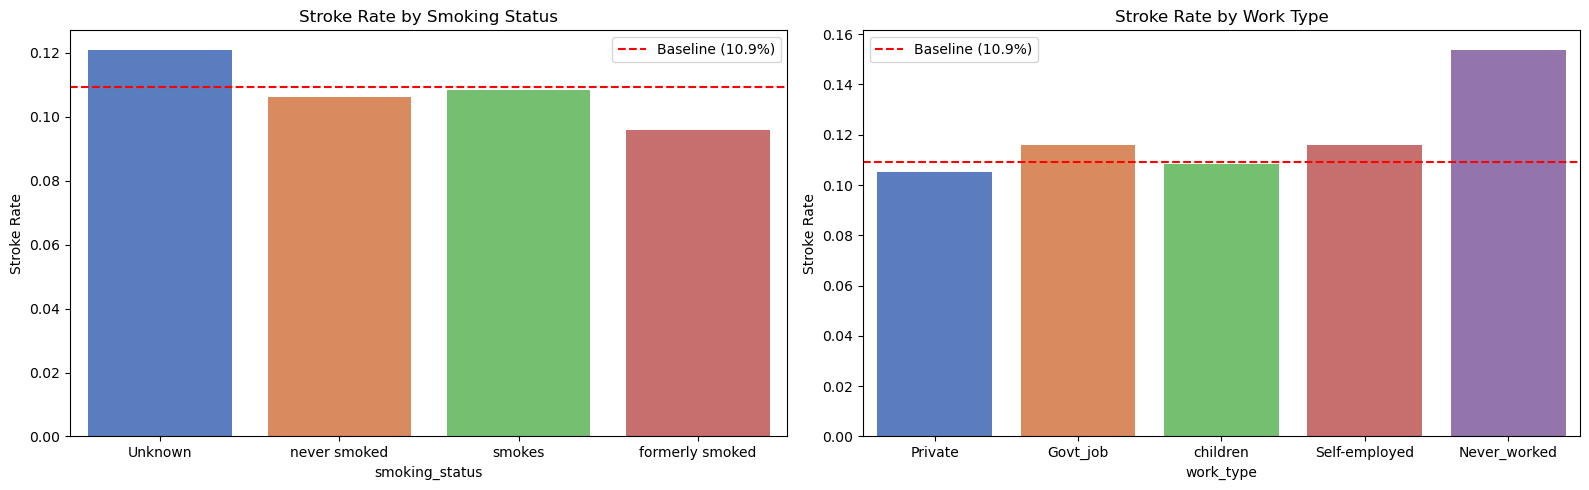

In [5]:
# 2. Stroke Rate by Categorical Lifestyle Factors

# Set up a grid for lifestyle plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Smoking Status vs Stroke Rate
sns.barplot(ax=axes[0], data=df, x='smoking_status', y='stroke', errorbar=None, palette='muted')
axes[0].axhline(baseline_rate, color='red', linestyle='--', label=f'Baseline ({baseline_rate:.1%})')
axes[0].set_title('Stroke Rate by Smoking Status')
axes[0].set_ylabel('Stroke Rate')
axes[0].legend()

# Plot Work Type vs Stroke Rate
sns.barplot(ax=axes[1], data=df, x='work_type', y='stroke', errorbar=None, palette='muted')
axes[1].axhline(baseline_rate, color='red', linestyle='--', label=f'Baseline ({baseline_rate:.1%})')
axes[1].set_title('Stroke Rate by Work Type')
axes[1].set_ylabel('Stroke Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


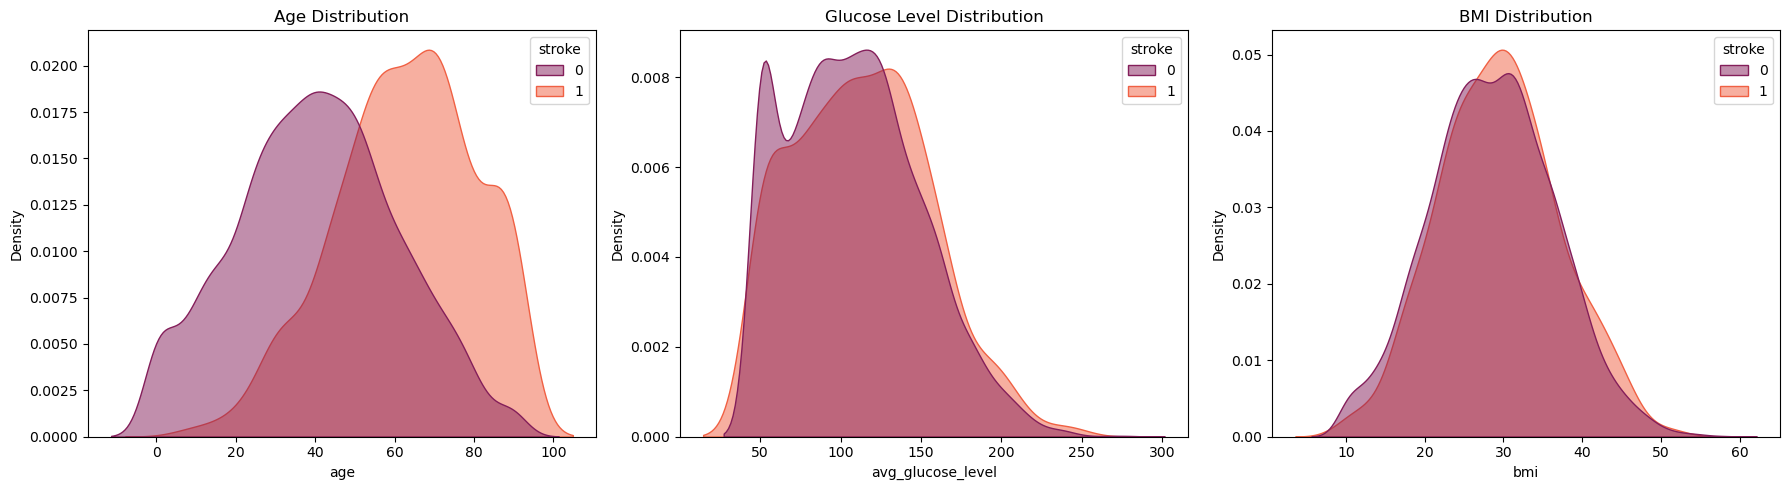

In [10]:
# 3. Stroke Rate by Continuous Numerical Factors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['age', 'avg_glucose_level', 'bmi']
titles = ['Age Distribution', 'Glucose Level Distribution', 'BMI Distribution']

for ax, feature, title in zip(axes, features, titles):
    sns.kdeplot(ax=ax, data=df, x=feature, hue='stroke', fill=True, common_norm=False, palette='rocket', alpha=0.5)
    ax.set_title(title)

plt.tight_layout()
plt.show()


**Q1 Takeaways:**
- Hypertension patients show ~3x the baseline stroke rate, confirming it as the strongest binary risk signal
- Age distributions diverge sharply — stroke cases skew significantly older, consistent with clinical literature
- BMI distributions overlap heavily between stroke/non-stroke groups — weak standalone predictor; likely interacts with age and glucose

## Q2 — Preprocessing Pipeline

In [ ]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Define our baseline features array layout
numeric_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['smoking_status', 'work_type', 'ever_married', 'Residence_type']
binary_passthrough = ['hypertension', 'heart_disease']

# 2. Swap out SimpleImputer for KNNImputer on the numeric branch
numeric_transformer_knn = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)), # Looks at the 5 closest passenger rows
    ('scaler', StandardScaler())
])

# 3. Streamlined Categorical Preprocessing 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# 4. Centralized ColumnTransformer 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_knn, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    # Keeps hypertension and heart_disease exactly as they are without alterations
    remainder='passthrough', 
    verbose_feature_names_out=False
)

## Q3 — GBM with Class Weight (SMOTE proxy)

In [34]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import classification_report, roc_auc_score

# 1. Split features and target
X = df.drop(columns=['stroke', 'id'], errors='ignore')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=420
)

# 2. Find binary column indices in the post-preprocessor matrix
# preprocessor outputs: [num (3 cols) | cat (OHE cols) | passthrough (2 cols)]
# Fit preprocessor on X_train alone to inspect output shape
_X_temp = preprocessor.fit_transform(X_train, y_train)
n_total_cols = _X_temp.shape[1]

# Binary passthrough columns land at the END of the transformed matrix
binary_indices = [n_total_cols - 2, n_total_cols - 1]  # hypertension, heart_disease
print(f"Transformed matrix shape: {_X_temp.shape}")
print(f"Binary feature indices passed to SMOTENC: {binary_indices}")

# 3. Build pipeline — preprocessor already fitted above so use transform only
# Reset preprocessor to refit cleanly inside the pipeline

# Rebuild preprocessor fresh so pipeline can refit it properly
preprocessor_fresh = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_fresh),
    ('smote', SMOTENC(categorical_features=binary_indices, random_state=420)),
    ('classifier', GradientBoostingClassifier(
        random_state=420,
        learning_rate=0.05,
        n_estimators=150
    ))
])

# 4. Train and evaluate
smote_pipeline.fit(X_train, y_train)
y_pred = smote_pipeline.predict(X_test)
y_proba = smote_pipeline.predict_proba(X_test)[:, 1]

# 5. Cross-validate for stable AUC estimate
cv_scores = cross_val_score(smote_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print(f"\nCV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n=== SMOTENC + Gradient Boosting Performance ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print(classification_report(y_test, y_pred))

Transformed matrix shape: (4088, 14)
Binary feature indices passed to SMOTENC: [12, 13]

CV AUC: 0.7652 ± 0.0110

=== SMOTENC + Gradient Boosting Performance ===
ROC-AUC Score: 0.7481

              precision    recall  f1-score   support

           0       0.93      0.80      0.86       910
           1       0.25      0.54      0.34       112

    accuracy                           0.77      1022
   macro avg       0.59      0.67      0.60      1022
weighted avg       0.86      0.77      0.80      1022



## Q4 — Threshold Tuning (Recall Focus)

In [35]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Get predicted probabilities for the stroke class (1)
y_proba = smote_pipeline.predict_proba(X_test)[:, 1]

# 2. Extract precision, recall, and corresponding thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

In [36]:
# Set your target clinical safety net (e.g., catching at least 85% of strokes)
target_recall = 0.85

# Find the index of the highest recall value that meets or exceeds our target
idx = np.where(recalls >= target_recall)[0][-1]

# Extract the specific threshold value at that exact index
optimal_threshold = thresholds[idx]

print(f"Optimal Threshold to achieve >= {target_recall:.0%} Recall: {optimal_threshold:.4f}")


Optimal Threshold to achieve >= 85% Recall: 0.1710


In [37]:
from sklearn.metrics import classification_report

# Apply the custom threshold mask
y_pred_clinical = (y_proba >= optimal_threshold).astype(int)

print(f"=== Clinical Focus Report (Threshold: {optimal_threshold:.4f}) ===")
print(classification_report(y_test, y_pred_clinical))


=== Clinical Focus Report (Threshold: 0.1710) ===
              precision    recall  f1-score   support

           0       0.96      0.48      0.64       910
           1       0.17      0.86      0.28       112

    accuracy                           0.52      1022
   macro avg       0.57      0.67      0.46      1022
weighted avg       0.88      0.52      0.60      1022



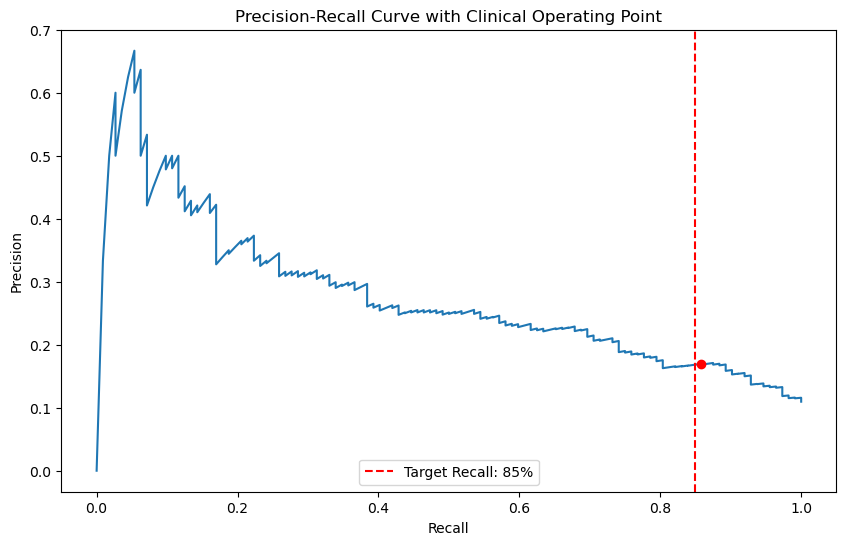

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(recalls[:-1], precisions[:-1])
plt.axvline(target_recall, color='red', linestyle='--', label=f'Target Recall: {target_recall:.0%}')
plt.scatter(recalls[idx], precisions[idx], color='red', zorder=5)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Clinical Operating Point')
plt.legend(); plt.show()

## Q5 — Feature Importance

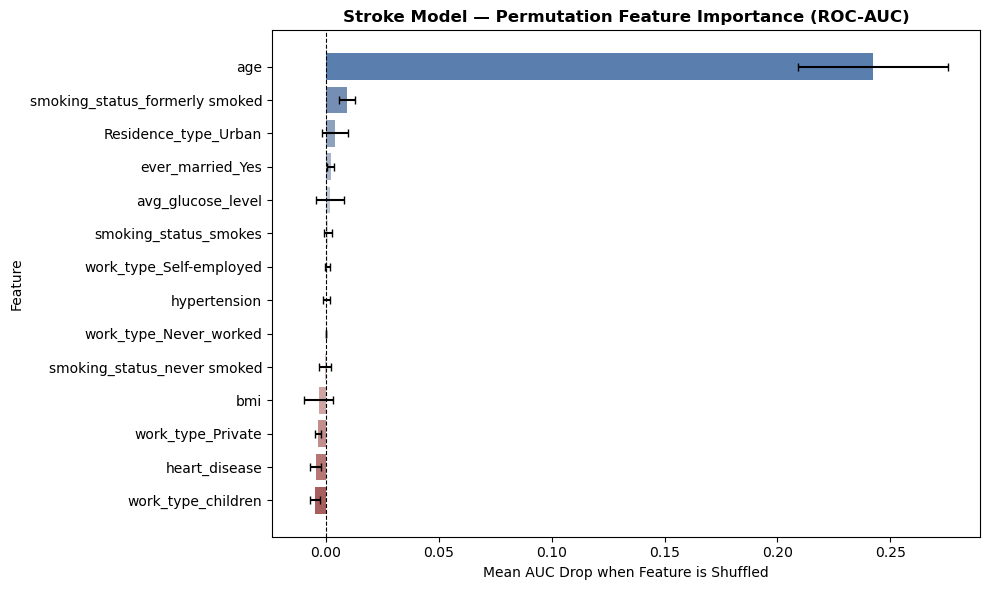

=== Permutation Importance Rankings ===
                       Feature  Importance      Std
                           age    0.242365 0.033155
smoking_status_formerly smoked    0.009188 0.003519
          Residence_type_Urban    0.004057 0.005704
              ever_married_Yes    0.002128 0.001506
             avg_glucose_level    0.001778 0.006289
         smoking_status_smokes    0.000802 0.001655
       work_type_Self-employed    0.000686 0.001244
                  hypertension    0.000228 0.001610
        work_type_Never_worked   -0.000127 0.000042
   smoking_status_never smoked   -0.000550 0.002615
                           bmi   -0.003281 0.006414
             work_type_Private   -0.003674 0.001390
                 heart_disease   -0.004492 0.002455
            work_type_children   -0.004923 0.002226


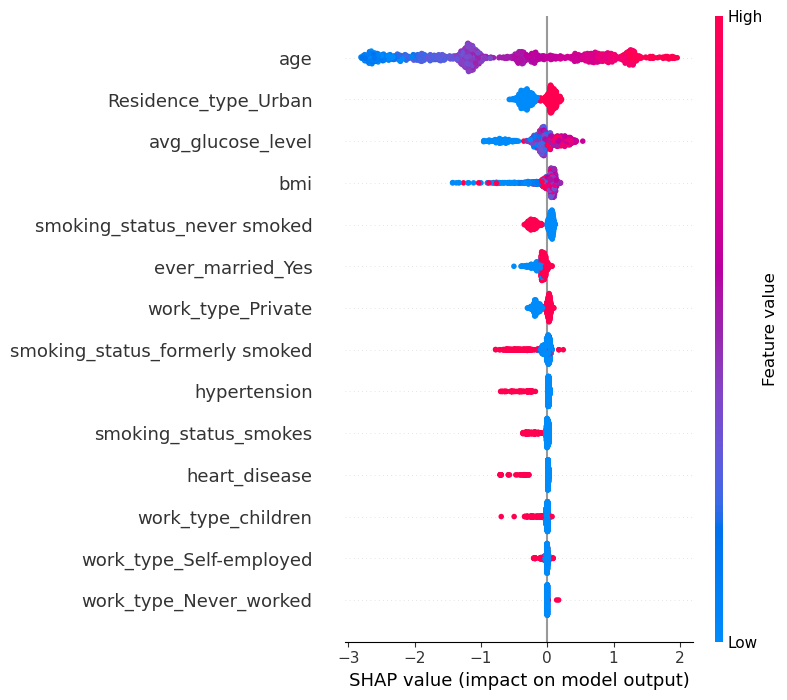

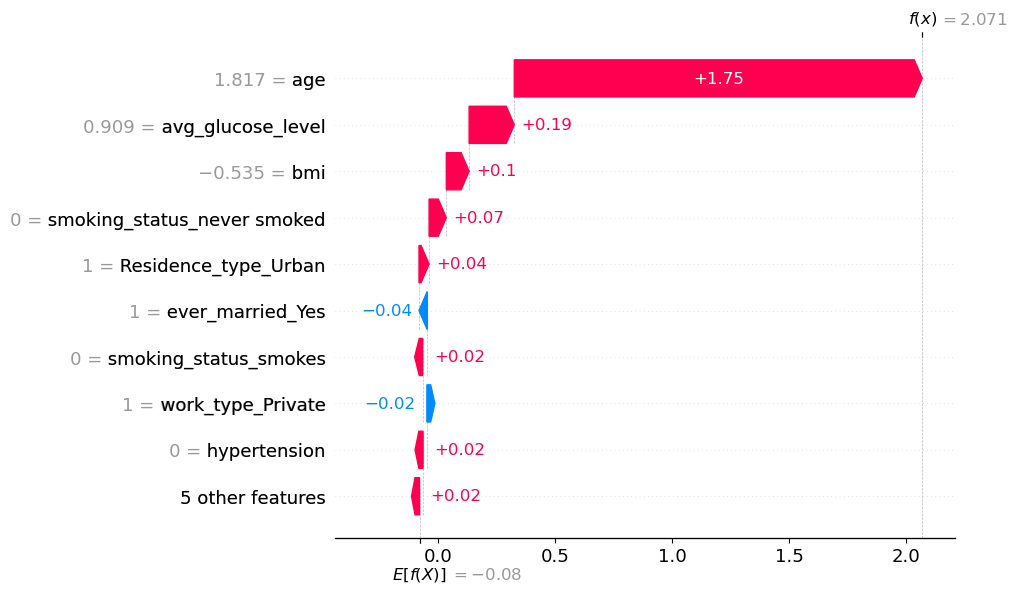


=== Clinical Interpretation ===

Top predictors of stroke risk:
  age                                  92.8% of predictive weight
  smoking_status_formerly smoked        3.5% of predictive weight
  Residence_type_Urban                  1.6% of predictive weight

Features with near-zero or negative permutation importance
(candidates for removal — validate with CV RMSE before dropping):
  work_type_Never_worked              -0.0001
  smoking_status_never smoked         -0.0006
  bmi                                 -0.0033
  work_type_Private                   -0.0037
  heart_disease                       -0.0045
  work_type_children                  -0.0049


In [43]:
import shap
from sklearn.inspection import permutation_importance

# ── 1. Transform X_test ────────────────────────────────────────────────────
X_test_transformed = (smote_pipeline
                      .named_steps['preprocessor']
                      .transform(X_test))

# Get feature names from fitted preprocessor
feature_names = (smote_pipeline
                 .named_steps['preprocessor']
                 .get_feature_names_out()
                 .tolist())
feature_names = [f.split('__')[-1] for f in feature_names]


# ── 2. Permutation Importance ──────────────────────────────────────────────
perm = permutation_importance(
    smote_pipeline.named_steps['classifier'],
    X_test_transformed,
    y_test,
    n_repeats=10,
    scoring='roc_auc',
    random_state=420
)

perm_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=perm_df, x='Importance', y='Feature',
            hue='Feature', legend=False, palette='vlag', ax=ax)
ax.errorbar(x=perm_df['Importance'], y=range(len(perm_df)),
            xerr=perm_df['Std'], fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Stroke Model — Permutation Feature Importance (ROC-AUC)',
             fontweight='bold')
ax.set_xlabel('Mean AUC Drop when Feature is Shuffled')
plt.tight_layout()
plt.show()

print("=== Permutation Importance Rankings ===")
print(perm_df.to_string(index=False))


# ── 3. SHAP ────────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(smote_pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# Beeswarm — global feature impact across all patients
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    plot_type='dot',
    show=True
)

# Waterfall — single highest-risk patient breakdown
highest_risk_idx = y_proba.argmax()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[highest_risk_idx],
        feature_names=feature_names
    )
)


# ── 4. Dynamic Commentary ──────────────────────────────────────────────────
total = perm_df['Importance'].clip(lower=0).sum()

top3 = perm_df.head(3)
low_impact = perm_df[perm_df['Importance'] <= 0]

print("\n=== Clinical Interpretation ===")
print(f"\nTop predictors of stroke risk:")
for _, row in top3.iterrows():
    share = row['Importance'] / total * 100 if total > 0 else 0
    print(f"  {row['Feature']:<35} {share:>5.1f}% of predictive weight")

print(f"\nFeatures with near-zero or negative permutation importance")
print(f"(candidates for removal — validate with CV RMSE before dropping):")
for _, row in low_impact.iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}")